[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_9_Exercises.ipynb)

# 11.9: Exercises

These exercises cover the full module: datetime indexing, resampling, rolling windows, period-over-period comparisons, and seasonal groupby patterns. All exercises use the same bike-sharing dataset from the instruction notebooks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
keep = ["dteday", "season", "weathersit", "temp", "casual", "registered", "cnt"]
df = pd.read_csv(url, usecols=keep, parse_dates=["dteday"],
                 index_col="dteday").sort_index()
print("Shape:", df.shape)
df.head()

Shape: (731, 6)


,season,weathersit,temp,casual,registered,cnt
dteday,,,,,,
2011-01-01,1,2,0.344167,331,654,985
2011-01-02,1,2,0.363478,131,670,801
2011-01-03,1,1,0.196364,120,1229,1349
2011-01-04,1,1,0.200000,108,1454,1562
2011-01-05,1,1,0.226957,82,1518,1600


---
## Part 1: Selecting Rows

### Exercise 1

First, a warm-up with a tool you already know. The `season` column encodes seasons as integers: 1 = spring, 2 = summer, 3 = fall, 4 = winter. Select only the rows from **winter** (season 4) across both years using boolean indexing on the `season` column. Print the number of rows and the total rental count for winter days.

The next exercise asks for a selection the new way, through the datetime index. Notice which approach feels more natural for which kind of job.

In [2]:
# your code here

In [3]:
#@title Solution
winter = df[df["season"] == 4]
print("Winter rows:", len(winter))
print("Total winter rentals:", winter["cnt"].sum())

Winter rows: 178
Total winter rentals: 841613


### Exercise 2

Use partial string indexing to select all rows from **the third quarter of 2012** (July, August, and September). Use `df.loc["2012-07":"2012-09"]` notation. Print the shape of the result and the mean daily rental count for that period.

In [4]:
# your code here

In [5]:
#@title Solution
q3_2012 = df.loc["2012-07":"2012-09"]
print("Shape:", q3_2012.shape)
print("Mean daily rentals:", q3_2012["cnt"].mean().round(1))

Shape: (92, 6)
Mean daily rentals: 6920.5


### Exercise 3

Print the date of the single day with the highest total rental count in the dataset, and the count on that day. Then print the date and count for the lowest day.

In [6]:
# your code here

In [7]:
#@title Solution
print("Peak day:    ", df["cnt"].idxmax().date(), "->", df["cnt"].max(), "rentals")
print("Lowest day:  ", df["cnt"].idxmin().date(), "->", df["cnt"].min(), "rentals")

Peak day:     2012-09-15 -> 8714 rentals
Lowest day:   2012-10-29 -> 22 rentals


---
## Part 2: Resampling

### Exercise 4

Compute the **weekly total** rentals using `.resample("W").sum()`. Plot the result as a line chart with the title "Weekly total bike rentals". How many weekly rows are there?

In [8]:
# your code here

Weekly rows: 106


<Axes: title={'center': 'Weekly total bike rentals'}, xlabel='dteday', ylabel='Rentals'>

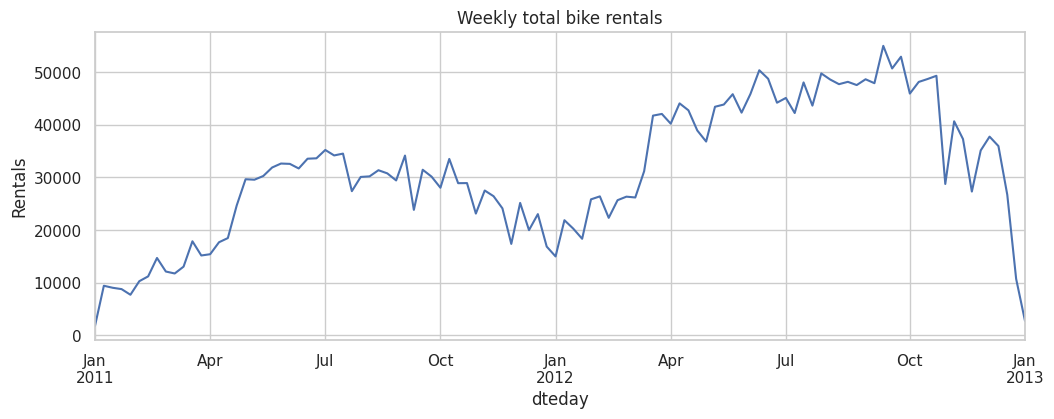

In [9]:
#@title Solution
weekly = df["cnt"].resample("W").sum()
print("Weekly rows:", len(weekly))
weekly.plot(figsize=(12, 4), title="Weekly total bike rentals", ylabel="Rentals")

### Exercise 5

Compute the **monthly mean** daily rentals using `.resample("ME").mean()`. Plot as a bar chart. Which month has the highest average? Which has the lowest? (Use `.idxmax()` and `.idxmin()` to find the answers.)

In [10]:
# your code here

Highest month:

 September 2012 -> 7285.8
Lowest month:  January 2011 -> 1231.9


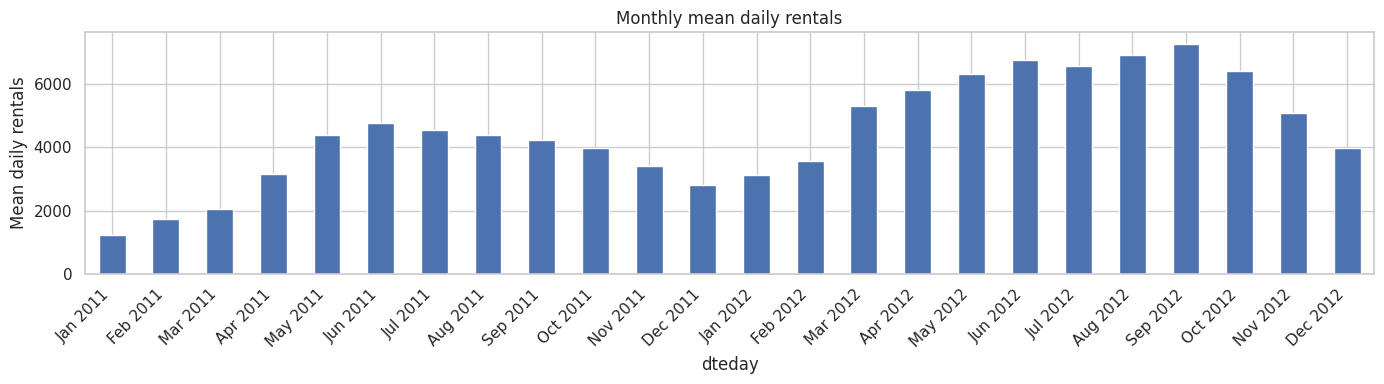

In [11]:
#@title Solution
monthly_mean = df["cnt"].resample("ME").mean().round(1)
ax = monthly_mean.plot(kind="bar", figsize=(14, 4),
                       title="Monthly mean daily rentals")
ax.set_ylabel("Mean daily rentals")
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly_mean.index], rotation=45, ha="right")
plt.tight_layout()

print("Highest month:", monthly_mean.idxmax().strftime("%B %Y"),
      "->", monthly_mean.max())
print("Lowest month: ", monthly_mean.idxmin().strftime("%B %Y"),
      "->", monthly_mean.min())

### Exercise 6

Compute the **quarterly total** rentals using `.resample("QE").sum()`. Print the result as a table. Which quarter had the most rentals across both years?

In [12]:
# your code here

In [13]:
#@title Solution
quarterly = df["cnt"].resample("QE").sum()
print(quarterly.to_string())
print()
print("Most rentals:", quarterly.idxmax().strftime("%b %Y"), "->", quarterly.max())

dteday
2011-03-31    150449
2011-06-30    374203
2011-09-30    405450
2011-12-31    313001
2012-03-31    364756
2012-06-30    572919
2012-09-30    636683
2012-12-31    475218
Freq: QE-DEC

Most rentals: Sep 2012 -> 636683


---
## Part 3: Rolling Windows

### Exercise 7

Compute a **14-day rolling mean** of `cnt`. Plot it on the same axes as the raw daily values. Use `alpha=0.35` for the raw series and a linewidth of 2 for the rolling mean. Add a legend and a title.

In [14]:
# your code here

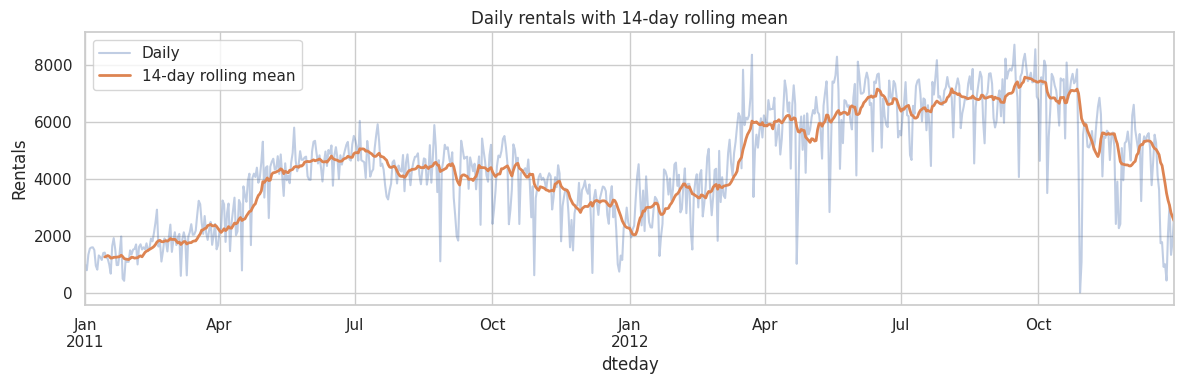

In [15]:
#@title Solution
fig, ax = plt.subplots(figsize=(12, 4))
df["cnt"].plot(ax=ax, alpha=0.35, label="Daily")
df["cnt"].rolling(14).mean().plot(ax=ax, linewidth=2, label="14-day rolling mean")
ax.set_title("Daily rentals with 14-day rolling mean")
ax.set_ylabel("Rentals")
ax.legend()
plt.tight_layout()

### Exercise 8

Plot a **7-day** and a **60-day** rolling mean of `cnt` on the same axes (no raw daily line this time). Add a legend and title. Describe in a comment what the 60-day line shows that the 7-day line cannot.

In [16]:
# your code here

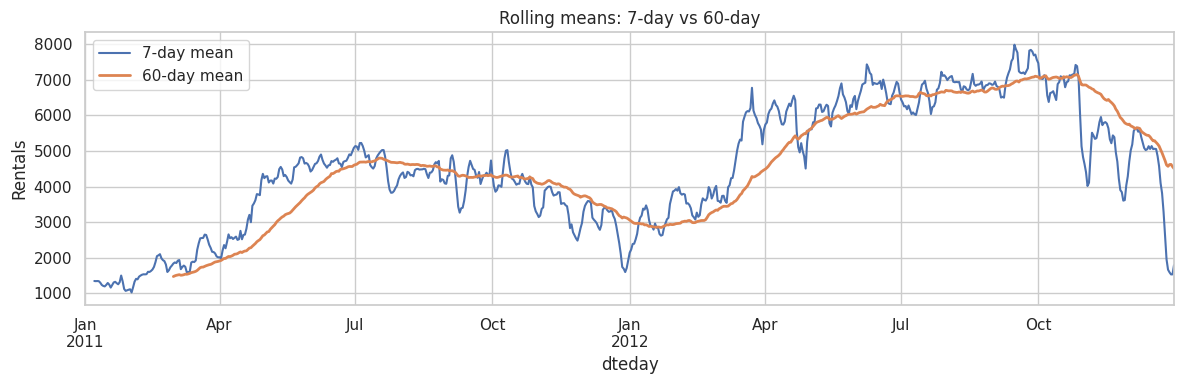

In [17]:
#@title Solution
fig, ax = plt.subplots(figsize=(12, 4))
df["cnt"].rolling(7).mean().plot(ax=ax, label="7-day mean")
df["cnt"].rolling(60).mean().plot(ax=ax, linewidth=2, label="60-day mean")
ax.set_title("Rolling means: 7-day vs 60-day")
ax.set_ylabel("Rentals")
ax.legend()
plt.tight_layout()
# The 60-day line shows the slow seasonal arc without any week-to-week noise.

---
## Part 4: Period-over-Period Comparisons

### Exercise 9

Compute the **day-over-day absolute change** in `cnt` using `.diff()`. Find the date of the single largest one-day drop and the single largest one-day gain. Print both dates and their change values.

In [18]:
# your code here

In [19]:
#@title Solution
daily_diff = df["cnt"].diff()
print("Largest one-day drop:")
print(" ", daily_diff.idxmin().date(), "->", int(daily_diff.min()), "rentals")
print("Largest one-day gain:")
print(" ", daily_diff.idxmax().date(), "->", int(daily_diff.max()), "rentals")

Largest one-day drop:
  2012-04-22 -> -5597 rentals
Largest one-day gain:
  2012-10-31 -> 4470 rentals


### Exercise 10

Compute the **month-over-month percent change** in monthly total rentals. Plot as a bar chart. In which calendar month (Jan, Feb, ...) does the biggest positive change typically occur? (Look at the chart, not just the raw numbers.)

In [20]:
# your code here

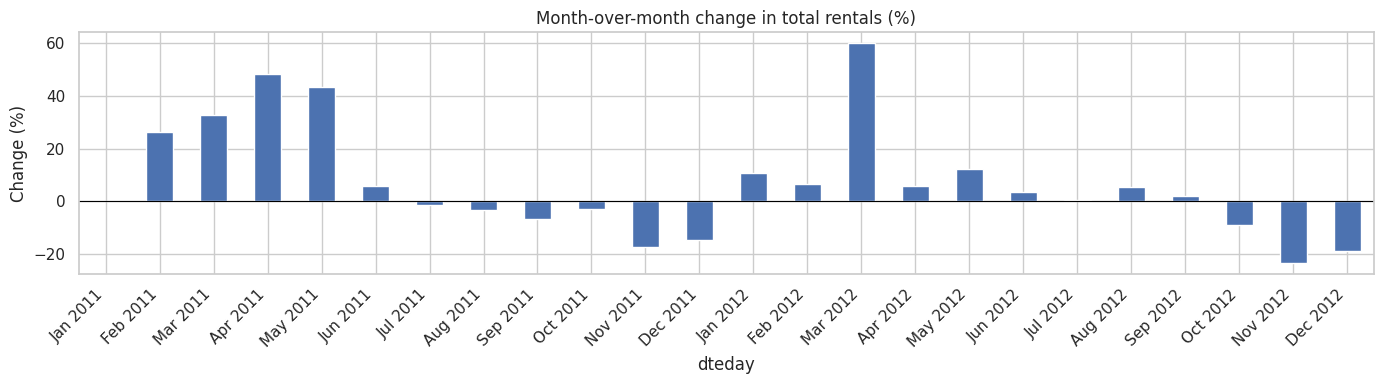

In [21]:
#@title Solution
monthly_sum = df["cnt"].resample("ME").sum()
mom = monthly_sum.pct_change()
ax = mom.mul(100).plot(kind="bar", figsize=(14, 4),
                       title="Month-over-month change in total rentals (%)")
ax.set_ylabel("Change (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels([d.strftime("%b %Y") for d in mom.index], rotation=45, ha="right")
plt.tight_layout()
# The biggest positive jumps tend to appear in March and April (spring return).

### Exercise 11

Compute the **year-over-year percent change** using `.pct_change(12)` on the monthly totals. Were there any months where 2012 had fewer rentals than the same month in 2011? Plot the result and print the month(s) where the value is negative, if any.

In [22]:
# your code here

No months where 2012 was below 2011.


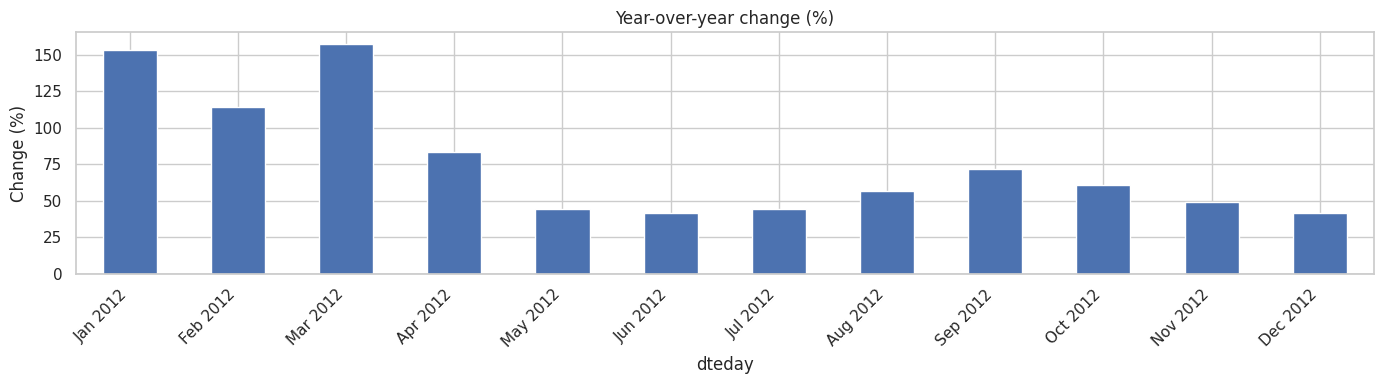

In [23]:
#@title Solution
yoy = monthly_sum.pct_change(12).dropna()
ax = yoy.mul(100).plot(kind="bar", figsize=(14, 4),
                       title="Year-over-year change (%)")
ax.set_ylabel("Change (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels([d.strftime("%b %Y") for d in yoy.index], rotation=45, ha="right")
plt.tight_layout()

negative = yoy[yoy < 0]
if len(negative) == 0:
    print("No months where 2012 was below 2011.")
else:
    print("Months with negative year-over-year change:")
    print(negative.to_string())

---
## Part 5: Seasonal Patterns

### Exercise 12

Compute the average daily rental count grouped by **day of week** (0=Monday through 6=Sunday). Relabel the index with short day names and plot as a bar chart. Which day of the week has the highest average total rentals?

In [24]:
# your code here

Highest day: Fri -> 4690.3


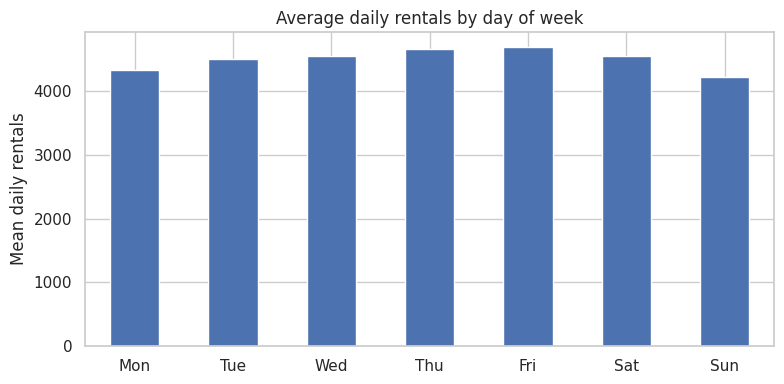

In [25]:
#@title Solution
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = df.groupby(df.index.dayofweek)["cnt"].mean().round(1)
by_dow.index = day_order
ax = by_dow.plot(kind="bar", figsize=(8, 4), title="Average daily rentals by day of week")
ax.set_ylabel("Mean daily rentals")
ax.set_xticklabels(day_order, rotation=0)
plt.tight_layout()
print("Highest day:", by_dow.idxmax(), "->", by_dow.max())

### Exercise 13

Compute the average daily `casual` and `registered` rental counts grouped by day of week. Plot them as two lines on the same axes. What does the crossover between the two lines (if there is one) tell you about the two types of riders?

In [26]:
# your code here

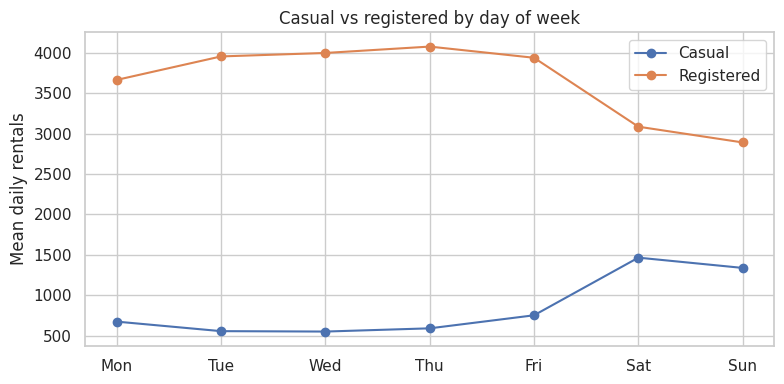

In [27]:
#@title Solution
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = df.groupby(df.index.dayofweek)[["casual", "registered"]].mean().round(1)
by_dow.index = day_order

fig, ax = plt.subplots(figsize=(8, 4))
by_dow["casual"].plot(ax=ax, marker="o", label="Casual")
by_dow["registered"].plot(ax=ax, marker="o", label="Registered")
ax.set_title("Casual vs registered by day of week")
ax.set_ylabel("Mean daily rentals")
ax.legend()
plt.tight_layout()
# Registered users peak midweek (commuters); casual users peak on weekends (recreation).

### Exercise 14 (Challenge)

Create a `pivot_table` with **`casual`** as the value, months (1-12) as columns, and days of the week (Mon-Sun) as rows, using `mean` as the aggregation. Relabel both axes with short names. Plot as a `sns.heatmap()` with `annot=True` and the color bar labeled "Mean daily casual rentals". Which single cell (month + day combination) has the highest average? In one sentence: how does this heatmap differ from the `cnt` heatmap in notebook 11.5, and what does the difference tell you about casual riders?

In [28]:
# your code here

Highest cell: Sat, May -> 2270 mean casual rentals


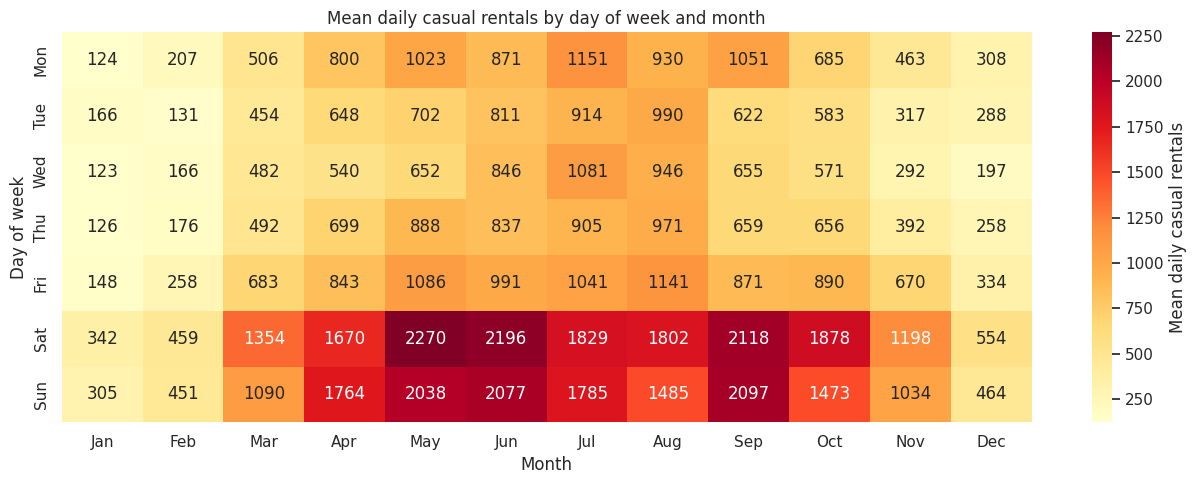

In [29]:
#@title Solution
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

pivot = df.pivot_table(values="casual",
                       index=df.index.dayofweek,
                       columns=df.index.month,
                       aggfunc="mean")
pivot.index = day_order
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Mean daily casual rentals"})
ax.set_title("Mean daily casual rentals by day of week and month")
ax.set_xlabel("Month")
ax.set_ylabel("Day of week")
plt.tight_layout()

# Find the cell with the highest value. This works because the table has a
# single global maximum, so the row max and column max that match it must
# both belong to that one cell.
max_val = pivot.max().max()
max_col = pivot.max(axis=0).idxmax()
max_row = pivot.max(axis=1).idxmax()
print(f"Highest cell: {max_row}, {max_col} -> {max_val:.0f} mean casual rentals")
# Unlike the cnt heatmap in 11.5, the hot cells here are almost entirely
# Saturdays and Sundays: casual riders are overwhelmingly weekend riders.